# Задание 1-3

In [39]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import re
import time

In [40]:
class Account:
    _account_counter = 1000

    def __init__(self, account_holder: str, balance: float = 0):
        Account._validate_holder_name(account_holder)
        if balance < 0:
            raise ValueError("Начальный баланс должен быть не отрицательным")

        Account._account_counter += 1

        self.holder = account_holder
        self._balance = balance
        self._account_counter = f"ACC-{Account._account_counter}"
        self.operations_history = []


        self._add_operation(
            operation_type="Create account",
            amount=balance,
            balance=self._balance,
            status="success"
        )

    def deposit(self, amount: float) -> None:
        """Пополнение средств на счёт"""
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной")

        self._balance += amount
        self._add_operation(
            operation_type="deposit",
            amount=amount,
            balance=self._balance,
            status="success"
        )

    def withdraw(self, amount: float) -> None:
        """Списание средств со счёта"""
        if amount <= 0:
            raise ValueError("Сумма списания должна быть положительной")

        if amount > self._balance:
            self._add_operation(
                operation_type="withdraw",
                amount=amount,
                balance=self._balance,
                status="fail"
            )
            return

        self._balance -= amount
        self._add_operation(
            operation_type="withdraw",
            amount=amount,
            balance=self._balance,
            status="success"
        )

    def get_balance(self) -> float:
        """Возвращает текущий баланс"""
        return self._balance

    def get_history(self) -> list:
        """Возвращает истории операций по счету"""
        return self.operations_history.copy()

    def plot_history(self) -> None:
        """Визуализирует историю операций изменения баланса"""
        if not self.operations_history:
            raise ValueError("История операций пуста, график построить невозможно")

        df = pd.DataFrame(self.operations_history)

        plt.figure(figsize=(10, 5))
        plt.plot(df["datetime"], df["balance"], marker="o", linestyle="-")
        plt.title(f"Изменение баланса по счету {self._account_counter}")
        plt.xlabel("Дата и время операции")
        plt.ylabel("Баланс, Р")
        plt.grid(True)
        plt.show()

    def get_top_operations(self, n: int = 5) -> list:
        """Возвращает топ n операций по счёту, отсротированных по дате"""
        top_operations = [
            op for op in self.operations_history
            if op["status"] == "success"
        ]

        sorted_operations = sorted(top_operations, key=lambda x: x["amount"], reverse=True)
        return sorted(sorted_operations[:n], key=lambda x: x["datetime"], reverse=True)

    def _add_operation(self, operation_type: str, amount: float, balance: float, status: str, dt: datetime = None) -> None:
        """Приватный метод добавления истории об операции"""
        self.operations_history.append({
            "type": operation_type,
            "amount": amount,
            "balance": balance,
            "datetime": (dt or datetime.now()).strftime("%Y-%m-%d %H:%M:%S"),
            "status": status
        })

    @staticmethod
    def _validate_holder_name(name: str) -> None:
        """Валидация имени клиента"""
        pattern = r"^[A-ZА-ЯЁ][a-zа-яё]+ [A-ZА-ЯЁ][a-zа-яё]+$"
        if not re.fullmatch(pattern, name):
            raise ValueError(
                "Имя владельца счёта должно быть в формате «Имя Фамилия»"
                "с заглавных букв, кириллицей или латиницей"
            )


In [41]:
class CheckingAccount(Account):
    account_type = "Checking"

    def load_history_from_file(self, path: str) -> None:
        """Загрузка истории счёта из файла"""
        if path.endswith(".csv"):
            df = pd.read_csv(path)
        elif path.endswith(".json"):
            df = pd.read_json(path)
        else:
            raise ValueError("Формат не поддерживается, используйте csv или json")

        df_clean = self.clean_history(df)

        for _, row in df_clean.iterrows():
            operation_type = row["operation"]
            amount = float(row["amount"])
            status = row["status"]
            dt = row["date"]

            if operation_type == "deposit":
                self._balance += amount
            elif operation_type == "withdraw":
                self._balance -= amount
            else:
                continue

            self._add_operation(
                    operation_type=operation_type,
                    amount=amount,
                    balance=self._balance,
                    dt=dt,
                    status=status
                )

    def clean_history(self, df: pd.DataFrame) -> pd.DataFrame:
        """Валидация данных на корректность"""
        df = df[df["account_number"] == self._account_counter]
        df = df[df["account_type"].str.lower() == self.account_type.lower()]
        df = df[df["operation"].isin(["deposit", "withdraw"])]
        df = df[df["status"] == "success"]
        df = df[df["amount"] > 0]
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"])

        return df

In [42]:
class SavingsAccount(Account):
    account_type = "Savings"

    def apply_interest(self, rate: float) -> None:
        """Расчёт процентов на остаток счёта"""
        if rate < 0 or rate > 100:
            raise ValueError("Процент должен 0 < rate <= 100")

        interest = self._balance * (rate / 100)
        self._balance += interest
        self._add_operation(
            operation_type="interest",
            amount=interest,
            balance=self.get_balance(),
            status="success"
        )

    def withdraw(self, amount: float) -> None:
        """Списание средств со счёта"""
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть больше нуля")

        if amount > self.get_balance() * 0.5:
            raise ValueError("Нельзя снять больше 50% от текущего баланса")

        self._balance -= amount

    def load_history_from_file(self, path: str) -> None:
        """Загрузка истории счёта из файла"""
        if path.endswith(".csv"):
            df = pd.read_csv(path)
        elif path.endswith(".json"):
            df = pd.read_json(path)
        else:
            raise ValueError("Формат не поддерживается, используйте csv или json")

        df_clean = self.clean_history(df)

        for _, row in df_clean.iterrows():
            operation_type = row["operation"]
            amount = float(row["amount"])
            status = row["status"]
            dt = row["date"]

            if operation_type == "deposit" and operation_type == "interest":
                self._balance += amount
            elif operation_type == "withdraw":
                self._balance -= amount
            else:
                continue

            self._add_operation(
                    operation_type=operation_type,
                    amount=amount,
                    balance=self._balance,
                    dt=dt,
                    status=status
                )

    def clean_history(self, df: pd.DataFrame) -> pd.DataFrame:
        """Валидация данных на корректность"""
        df = df[df["account_number"] == self._account_counter]
        df = df[df["account_type"].str.lower() == self.account_type.lower()]
        df = df[df["operation"].isin(["deposit", "withdraw", "interest"])]
        df = df[df["status"] == "success"]
        df = df[df["amount"] > 0]
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"])

        return df

# Демонстрация работы

## Задание 1

Создаём счёт и заполняем его данными

In [43]:
account = Account("Anton Pitsenko", 1000)

In [44]:
account.deposit(100)
time.sleep(5)
account.deposit(150)
account.deposit(170)
time.sleep(5)
account.withdraw(100)
account.deposit(190)
time.sleep(5)
account.deposit(100)
account.withdraw(100)
account.withdraw(150)

Получаем историю операций по счёту

In [45]:
account.get_history()

[{'type': 'Create account',
  'amount': 1000,
  'balance': 1000,
  'datetime': '2025-11-08 11:36:39',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 100,
  'balance': 1100,
  'datetime': '2025-11-08 11:36:39',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 150,
  'balance': 1250,
  'datetime': '2025-11-08 11:36:44',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 170,
  'balance': 1420,
  'datetime': '2025-11-08 11:36:44',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 100,
  'balance': 1320,
  'datetime': '2025-11-08 11:36:49',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 190,
  'balance': 1510,
  'datetime': '2025-11-08 11:36:49',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 100,
  'balance': 1610,
  'datetime': '2025-11-08 11:36:54',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 100,
  'balance': 1510,
  'datetime': '2025-11-08 11:36:54',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 150,
  'bala

Получаем баланс счёта

In [46]:
account.get_balance()

1360

График изменения баланса на счёте

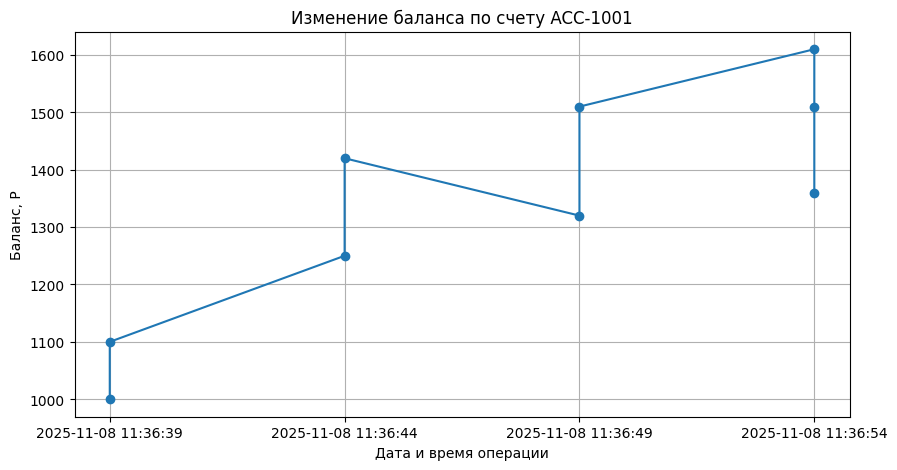

In [47]:
account.plot_history()

Демонстрация того, что нельзя пополнить баланс на -1000

In [48]:
account.deposit(-1000)

ValueError: Сумма пополнения должна быть положительной

Демонстрация того, что нельзя списать со счёта отрицательную сумму

In [49]:
account.withdraw(-1000)

ValueError: Сумма списания должна быть положительной

## Задание 2

Создаём объекты для checking и savings счётов

In [50]:
checking_account = CheckingAccount("Евгений Меньшов", 10000)
savings_account = SavingsAccount("Иван Петров", 10000)

Демонстрация работы метода apply_interest: смотрим баланс до применения метода, затем применяем метод с процентной ставкой 10 и проверяем баланс после его применения

In [51]:
print(savings_account.get_balance())
savings_account.apply_interest(10)
print(savings_account.get_balance())

10000
11000.0


Демонстрация, что метод withdraw в SavingsAccount не дает списать больше 50 процентов

In [52]:
savings_account.withdraw(7000)

ValueError: Нельзя снять больше 50% от текущего баланса

Демонстрация валидации имени и попытки внести отрицательную сумму

In [53]:
Account("Антон")

ValueError: Имя владельца счёта должно быть в формате «Имя Фамилия»с заглавных букв, кириллицей или латиницей

In [54]:
Account("Антон Пиценко", -1000)

ValueError: Начальный баланс должен быть не отрицательным

Объект account был создан в задании 1

Получаем топ операция счёта отсортированных по дате (по дефолту 5 операций, можно задать через параметр своё число)

In [55]:
account.get_top_operations()

[{'type': 'withdraw',
  'amount': 150,
  'balance': 1360,
  'datetime': '2025-11-08 11:36:54',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 190,
  'balance': 1510,
  'datetime': '2025-11-08 11:36:49',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 170,
  'balance': 1420,
  'datetime': '2025-11-08 11:36:44',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 150,
  'balance': 1250,
  'datetime': '2025-11-08 11:36:44',
  'status': 'success'},
 {'type': 'Create account',
  'amount': 1000,
  'balance': 1000,
  'datetime': '2025-11-08 11:36:39',
  'status': 'success'}]

## Задание 3

Создаём объекты для checking и savings счётов

In [56]:
checking_account = CheckingAccount("Евгений Меньшов", 10000)
checking_account._account_counter = "ACC-100001"
savings_account = SavingsAccount("Иван Петров", 10000)
savings_account._account_counter = "ACC-100004"

Заполняем историю операций счёта checking из файлов

In [57]:
checking_account.load_history_from_file("transactions_dirty.csv")
checking_account.load_history_from_file("transactions_dirty.json")

Проверяем баланс после загрузки данных

In [58]:
checking_account.get_balance()

16680.0

Проверяем историю после загрузки данных

In [59]:
checking_account.get_history()

[{'type': 'Create account',
  'amount': 10000,
  'balance': 10000,
  'datetime': '2025-11-08 11:37:40',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 921.0,
  'balance': 10921.0,
  'datetime': '2025-09-27 22:17:26',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 607.0,
  'balance': 11528.0,
  'datetime': '2025-09-27 22:17:26',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 488.0,
  'balance': 12016.0,
  'datetime': '2025-09-28 22:17:26',
  'status': 'success'},
 {'type': 'deposit',
  'amount': 880.0,
  'balance': 12896.0,
  'datetime': '2025-09-29 22:17:26',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 352.0,
  'balance': 12544.0,
  'datetime': '2025-10-01 22:17:26',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 65.0,
  'balance': 12479.0,
  'datetime': '2025-10-01 22:17:26',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 245.0,
  'balance': 12234.0,
  'datetime': '2025-10-01 22:17:26',
  'status': 'success'},
 {'type':

Загружаем историю операций для счёта savings из файлов

In [60]:
savings_account.load_history_from_file("transactions_dirty.csv")
savings_account.load_history_from_file("transactions_dirty.json")

Проверяем баланс после загрузки данных

In [61]:
savings_account.get_balance()

9000.0

Проверяем историю после загрузки данных

In [62]:
savings_account.get_history()

[{'type': 'Create account',
  'amount': 10000,
  'balance': 10000,
  'datetime': '2025-11-08 11:37:40',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 209.0,
  'balance': 9791.0,
  'datetime': '2025-10-05 22:17:26',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 291.0,
  'balance': 9500.0,
  'datetime': '2025-10-13 22:17:26',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 209.0,
  'balance': 9291.0,
  'datetime': '2025-10-05 22:17:26',
  'status': 'success'},
 {'type': 'withdraw',
  'amount': 291.0,
  'balance': 9000.0,
  'datetime': '2025-10-13 22:17:26',
  'status': 'success'}]